# Library and Data Imports and Standardization

In [1]:
# Install xgboost
!pip install xgboost

In [2]:
# Make the imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import sklearn as sk

# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Import ordinal encoder
from sklearn.preprocessing import OrdinalEncoder

# Import Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, make_scorer, r2_score, root_mean_squared_error

# Import train test split
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn import svm
from sklearn.kernel_approximation import RBFSampler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
from pprint import pprint

# Import Gradient Boosting Regressor and Classifier
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier

# Import time
import time

# Import Randomized Search CV
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

# Import confusion matrix
from sklearn.metrics import confusion_matrix

# Import kfold
from sklearn.model_selection import KFold

# Import cross val score
from sklearn.model_selection import cross_val_score

# Import math
import math

# Import log2
from math import log2

# Import classification report
from sklearn.metrics import classification_report

# Import pickle
import pickle

np.random.seed(42)

from xgboost import XGBClassifier
from xgboost import XGBRegressor

# Import class weights
from sklearn.utils.class_weight import compute_class_weight

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
balance = "Weighted"
name = "weighted"
data = "imbalanced"

In [4]:
path = '/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/'
# path = 'data/'
pickle_path = '/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/pickle/'
# pickle_path = 'pickle/'
results_path = '/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/results/'
# results_path = 'results/'

convabuse_filename = f'convabuse_{data}.csv'
dghs_filename = f'dynamically_generated_hate_speech_dataset_{data}.csv'
oaa_filename = f'online_abusive_attacks_class_{data}.csv'
us2020hs_filename = f'us_elections_2020_hate_speech_{data}.csv'
mlma_hate_speech_filename = f'MLMA_hate_speech_{data}.csv'

In [5]:
# Import the datasets
convabuse = pd.read_csv(f'{path}{convabuse_filename}')
convabuse_sample = convabuse.sample(frac=0.01, random_state=42)
dynamically_generated_hate_speech = pd.read_csv(f'{path}{dghs_filename}')
dynamically_generated_hate_speech_sample = dynamically_generated_hate_speech.sample(frac=0.01, random_state=42)
online_abusive_attacks = pd.read_csv(f'{path}{oaa_filename}')
online_abusive_attacks_sample = online_abusive_attacks.sample(frac=0.01, random_state=42)
us_elections_2020_hate_speech = pd.read_csv(f'{path}{us2020hs_filename}')
us_elections_2020_hate_speech_sample = us_elections_2020_hate_speech.sample(frac=0.01, random_state=42)
mlma_hate_speech = pd.read_csv(f'{path}{mlma_hate_speech_filename}')
mlma_hate_speech_sample = mlma_hate_speech.sample(frac=0.01, random_state=42)

In [6]:
convabuse.head()

,annotator_id,bot,generalised,individual,system,explicit,implicit,abuse_level,target_groups
0,7,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,1,0
2,7,0,0,0,0,0,0,0,0
3,7,1,0,0,0,0,0,0,0
4,7,0,0,0,0,0,0,0,0


In [7]:
convabuse_X = convabuse.drop("abuse_level", axis=1)
convabuse_y = convabuse["abuse_level"]
convabuse_X_sample = convabuse_sample.drop("abuse_level", axis=1)
convabuse_y_sample = convabuse_sample["abuse_level"]

In [8]:
dynamically_generated_hate_speech.head()

,label,type,annotator,target_groups,original
0,1.0,0,3,0,1
1,1.0,0,3,0,1
2,1.0,0,18,0,1
3,1.0,0,16,0,1
4,1.0,0,7,0,1


In [9]:
dghs_X = dynamically_generated_hate_speech.drop("label", axis=1)
dghs_y = dynamically_generated_hate_speech["label"]
dghs_X_sample = dynamically_generated_hate_speech_sample.drop("label", axis=1)
dghs_y_sample = dynamically_generated_hate_speech_sample["label"]

In [10]:
online_abusive_attacks.head()

,Toxic parent tweets,Toxic replies,Toxic Level
0,0.0,0.0,0
1,67.0,13.0,2
2,28.0,45.0,2
3,47.0,49.0,2
4,97.0,7.0,3


In [11]:
online_abusive_attacks_X = online_abusive_attacks.drop("Toxic Level", axis=1)
online_abusive_attacks_y = online_abusive_attacks["Toxic Level"]
online_abusive_attacks_X_sample = online_abusive_attacks_sample.drop("Toxic Level", axis=1)
online_abusive_attacks_y_sample = online_abusive_attacks_sample["Toxic Level"]

In [12]:
us_elections_2020_hate_speech.head()

,Trump,Biden,West,HOF
0,1,0,1,0
1,1,0,1,0
2,-1,0,1,0
3,0,0,1,0
4,0,1,1,0


In [13]:
us2020hs_X = us_elections_2020_hate_speech.drop("HOF", axis=1)
us2020hs_y = us_elections_2020_hate_speech["HOF"]
us2020hs_X_sample = us_elections_2020_hate_speech_sample.drop("HOF", axis=1)
us2020hs_y_sample = us_elections_2020_hate_speech_sample["HOF"]

In [14]:
mlma_hate_speech.head()

,implicit,explicit,target_groups,annotator_sentiment,abuse_level
0,1,0,1,2,2
1,1,0,0,6,1
2,1,0,0,0,1
3,0,1,1,0,1
4,1,0,1,0,1


In [15]:
mlma_hate_speech_X = mlma_hate_speech.drop("target_groups", axis=1)
mlma_hate_speech_y = mlma_hate_speech["target_groups"]
mlma_hate_speech_X_sample = mlma_hate_speech_sample.drop("target_groups", axis=1)
mlma_hate_speech_y_sample = mlma_hate_speech_sample["target_groups"]

# Linear Modeling

In [16]:
# Get only the numeric features for each dataset
convabuse_X_numeric = convabuse_X.select_dtypes(include=np.number)
convabuse_X_numeric_sample = convabuse_X_sample.select_dtypes(include=np.number)
dghs_X_numeric = dghs_X.select_dtypes(include=np.number)
dghs_X_numeric_sample = dghs_X_sample.select_dtypes(include=np.number)
online_abusive_attacks_X_numeric = online_abusive_attacks_X.select_dtypes(include=np.number)
online_abusive_attacks_X_numeric_sample = online_abusive_attacks_X_sample.select_dtypes(include=np.number)
us2020hs_X_numeric = us2020hs_X.select_dtypes(include=np.number)
us2020hs_X_numeric_sample = us2020hs_X_sample.select_dtypes(include=np.number)
mlma_hate_speech_X_numeric = mlma_hate_speech_X.select_dtypes(include=np.number)
mlma_hate_speech_X_numeric_sample = mlma_hate_speech_X_sample.select_dtypes(include=np.number)

In [17]:
# Use standard scaler on the Convabuse X data
convabuse_scaler = StandardScaler()
convabuse_X_scaled = convabuse_scaler.fit_transform(convabuse_X_numeric)
convabuse_X_scaled = pd.DataFrame(convabuse_X_scaled, columns=convabuse_X_numeric.columns)
convabuse_sample_scaler = StandardScaler()
convabuse_X_scaled_sample = convabuse_sample_scaler.fit_transform(convabuse_X_numeric_sample)
convabuse_X_scaled_sample = pd.DataFrame(convabuse_X_scaled_sample, columns=convabuse_X_numeric_sample.columns)

In [18]:
# Use standard scaler on the Dynamically Generated Hate Speech X data
dghs_scaler = StandardScaler()
dghs_X_scaled = dghs_scaler.fit_transform(dghs_X_numeric)
dghs_X_scaled = pd.DataFrame(dghs_X_scaled, columns=dghs_X_numeric.columns)
dghs_sample_scaler = StandardScaler()
dghs_X_scaled_sample = dghs_sample_scaler.fit_transform(dghs_X_numeric_sample)
dghs_X_scaled_sample = pd.DataFrame(dghs_X_scaled_sample, columns=dghs_X_numeric_sample.columns)

In [19]:
# Use standard scaler on the online abusive attacks X data
oaa_scaler = StandardScaler()
online_abusive_attacks_X_scaled = oaa_scaler.fit_transform(online_abusive_attacks_X_numeric)
online_abusive_attacks_X_scaled = pd.DataFrame(online_abusive_attacks_X_scaled, columns=online_abusive_attacks_X_numeric.columns)
online_abusive_attacks_sample_scaler = StandardScaler()
online_abusive_attacks_X_scaled_sample = online_abusive_attacks_sample_scaler.fit_transform(online_abusive_attacks_X_numeric_sample)
online_abusive_attacks_X_scaled_sample = pd.DataFrame(online_abusive_attacks_X_scaled_sample, columns=online_abusive_attacks_X_numeric_sample.columns)

In [20]:
# Use standard scaler on the US elections 2020 hate speech X data
us2020hs_scaler = StandardScaler()
us2020hs_X_scaled = us2020hs_scaler.fit_transform(us2020hs_X_numeric)
us2020hs_X_scaled = pd.DataFrame(us2020hs_X_scaled, columns=us2020hs_X_numeric.columns)
us2020hs_sample_scaler = StandardScaler()
us2020hs_X_scaled_sample = us2020hs_sample_scaler.fit_transform(us2020hs_X_numeric_sample)
us2020hs_X_scaled_sample = pd.DataFrame(us2020hs_X_scaled_sample, columns=us2020hs_X_numeric_sample.columns)

In [21]:
# Use standard scaler on the MLMA hate speech X data
mlma_hate_speech_scaler = StandardScaler()
mlma_hate_speech_X_scaled = mlma_hate_speech_scaler.fit_transform(mlma_hate_speech_X_numeric)
mlma_hate_speech_X_scaled = pd.DataFrame(mlma_hate_speech_X_scaled, columns=mlma_hate_speech_X_numeric.columns)
mlma_hate_speech_sample_scaler = StandardScaler()
mlma_hate_speech_X_sample_scaled = mlma_hate_speech_sample_scaler.fit_transform(mlma_hate_speech_X_numeric_sample)
mlma_hate_speech_X_sample_scaled = pd.DataFrame(mlma_hate_speech_X_sample_scaled, columns=mlma_hate_speech_X_numeric_sample.columns)

In [22]:
for columns in [convabuse_X_numeric.columns, dghs_X_numeric.columns, online_abusive_attacks_X_numeric.columns, us2020hs_X_numeric.columns, mlma_hate_speech_X_numeric.columns]:
  print(columns)

Index(['annotator_id', 'bot', 'generalised', 'individual', 'system',
       'explicit', 'implicit', 'target_groups'],
      dtype='object')
Index(['type', 'annotator', 'target_groups', 'original'], dtype='object')
Index(['Toxic parent tweets', 'Toxic replies'], dtype='object')
Index(['Trump', 'Biden', 'West'], dtype='object')
Index(['implicit', 'explicit', 'annotator_sentiment', 'abuse_level'], dtype='object')


In [23]:
# Train test split for each dataset
convabuse_X_train, convabuse_X_test, convabuse_y_train, convabuse_y_test = train_test_split(convabuse_X_scaled, convabuse_y, test_size=0.2, random_state=42, stratify=convabuse_y)
convabuse_X_train_sample, convabuse_X_test_sample, convabuse_y_train_sample, convabuse_y_test_sample = train_test_split(convabuse_X_scaled_sample, convabuse_y_sample, test_size=0.2, random_state=42, stratify=convabuse_y_sample)

dghs_X_train, dghs_X_test, dghs_y_train, dghs_y_test = train_test_split(dghs_X_scaled, dghs_y, test_size=0.2, random_state=42, stratify=dghs_y)
dghs_X_train_sample, dghs_X_test_sample, dghs_y_train_sample, dghs_y_test_sample = train_test_split(dghs_X_scaled_sample, dghs_y_sample, test_size=0.2, random_state=42, stratify=dghs_y_sample)

oaa_X_train, oaa_X_test, oaa_y_train, oaa_y_test = train_test_split(online_abusive_attacks_X_scaled, online_abusive_attacks_y, test_size=0.2, random_state=42)
oaa_X_train_sample, oaa_X_test_sample, oaa_y_train_sample, oaa_y_test_sample = train_test_split(online_abusive_attacks_X_scaled_sample, online_abusive_attacks_y_sample, test_size=0.2, random_state=42)

us2020hs_X_train, us2020hs_X_test, us2020hs_y_train, us2020hs_y_test = train_test_split(us2020hs_X_scaled, us2020hs_y, test_size=0.2, random_state=42, stratify=us2020hs_y)
us2020hs_X_train_sample, us2020hs_X_test_sample, us2020hs_y_train_sample, us2020hs_y_test_sample = train_test_split(us2020hs_X_scaled_sample, us2020hs_y_sample, test_size=0.2, random_state=42, stratify=us2020hs_y_sample)

mlma_hate_speech_X_train, mlma_hate_speech_X_test, mlma_hate_speech_y_train, mlma_hate_speech_y_test = train_test_split(mlma_hate_speech_X_scaled, mlma_hate_speech_y, test_size=0.2, random_state=42, stratify=mlma_hate_speech_y)
mlma_hate_speech_X_train_sample, mlma_hate_speech_X_test_sample, mlma_hate_speech_y_train_sample, mlma_hate_speech_y_test_sample = train_test_split(mlma_hate_speech_X_sample_scaled, mlma_hate_speech_y_sample, test_size=0.2, random_state=42, stratify=mlma_hate_speech_y_sample)

In [24]:
# Get the length of each dataset
convabuse_length = len(convabuse_X_train_sample)
dghs_length = len(dghs_X_train_sample)
online_abusive_attacks_length = len(oaa_X_train_sample)
us2020hs_length = len(us2020hs_X_train_sample)
mlma_hate_speech_length = len(mlma_hate_speech_X_train_sample)

In [25]:
convabuse_log2 = math.ceil(log2(convabuse_length))
convabuse_1_percent = math.ceil(convabuse_length * 0.01)
convabuse_length, convabuse_log2, convabuse_1_percent

(100, 7, 1)

In [26]:
convabuse_sample_log2 = math.ceil(log2(convabuse_length))
convabuse_sample_1_percent = math.ceil(convabuse_length * 0.01)
convabuse_length, convabuse_sample_log2, convabuse_sample_1_percent

(100, 7, 1)

In [27]:
dghs_log2 = math.ceil(log2(dghs_length))
dghs_1_percent = math.ceil(dghs_length * 0.01)
dghs_length, dghs_log2, dghs_1_percent

(327, 9, 4)

In [28]:
online_abusive_attacks_log2 = math.ceil(log2(online_abusive_attacks_length))
online_abusive_attacks_1_percent = math.ceil(online_abusive_attacks_length * 0.01)
online_abusive_attacks_length, online_abusive_attacks_log2, online_abusive_attacks_1_percent

(18, 5, 1)

In [29]:
us2020hs_log2 = math.ceil(log2(us2020hs_length))
us2020hs_1_percent = math.ceil(us2020hs_length * 0.01)
us2020hs_length, us2020hs_log2, us2020hs_1_percent

(24, 5, 1)

In [30]:
mlma_hate_speech_log2 = math.ceil(log2(mlma_hate_speech_length))
mlma_hate_speech_1_percent = math.ceil(mlma_hate_speech_length * 0.01)
mlma_hate_speech_length, mlma_hate_speech_log2, mlma_hate_speech_1_percent

(149, 8, 2)

In [31]:
mlma_hate_speech_sample_log2 = math.ceil(log2(mlma_hate_speech_length))
mlma_hate_speech_sample_1_percent = math.ceil(mlma_hate_speech_length * 0.01)
mlma_hate_speech_length, mlma_hate_speech_sample_log2, mlma_hate_speech_sample_1_percent

(149, 8, 2)

In [32]:
gb_classification_results_list = []

In [33]:
# Calculate sample weights for Convabuse training data
convabuse_sample_weights = compute_class_weight('balanced', classes=np.unique(convabuse_y_train_sample), y=convabuse_y_train_sample)
convabuse_sample_weights = {cls: weight for cls, weight in zip(np.unique(convabuse_y_train_sample), convabuse_sample_weights)}
convabuse_sample_weights_array = np.array([convabuse_sample_weights[i] for i in convabuse_y_train_sample])

# Calculate sample weights for Dynamically Generated Hate Speech training data
dghs_sample_weights = compute_class_weight('balanced', classes=np.unique(dghs_y_train_sample), y=dghs_y_train_sample)
dghs_sample_weights = {cls: weight for cls, weight in zip(np.unique(dghs_y_train_sample), dghs_sample_weights)}
dghs_sample_weights_array = np.array([dghs_sample_weights[i] for i in dghs_y_train_sample])

# Calculate sample weights for the Online Abusive Attacks training data
oaa_sample_weights = compute_class_weight('balanced', classes=np.unique(oaa_y_train_sample), y=oaa_y_train_sample)
oaa_sample_weights = {cls: weight for cls, weight in zip(np.unique(oaa_y_train_sample), oaa_sample_weights)}
oaa_sample_weights_array = np.array([oaa_sample_weights[i] for i in oaa_y_train_sample])

# Calculate sample weights for US Elections 2020 Hate Speech training data
us2020hs_sample_weights = compute_class_weight('balanced', classes=np.unique(us2020hs_y_train_sample), y=us2020hs_y_train_sample)
us2020hs_sample_weights = {cls: weight for cls, weight in zip(np.unique(us2020hs_y_train_sample), us2020hs_sample_weights)}
us2020hs_sample_weights_array = np.array([us2020hs_sample_weights[i] for i in us2020hs_y_train_sample])

# Calculate sample weights for MLMA Hate Speech training data
mlma_hate_speech_sample_weights = compute_class_weight('balanced', classes=np.unique(mlma_hate_speech_y_train_sample), y=mlma_hate_speech_y_train_sample)
mlma_hate_speech_sample_weights = {cls: weight for cls, weight in zip(np.unique(mlma_hate_speech_y_train_sample), mlma_hate_speech_sample_weights)}
mlma_hate_speech_sample_weights_array = np.array([mlma_hate_speech_sample_weights[i] for i in mlma_hate_speech_y_train_sample])

## Convabuse Decision Tree

In [34]:
convabuse_y_test_sample.value_counts()

,count
abuse_level,
0,21
3,2
4,1
2,1
1,1


In [35]:
convabuse_X_sample_split_count = int((len(convabuse_X_train_sample) / 10))
convabuse_X_sample_split_count

10

In [36]:
# Create a pipeline for the XGBoost Classifier for the Convabuse dataset optimized for accuracy
convabuse_gb_pipeline = Pipeline([
    ('xgb', XGBClassifier(random_state=42))
])

# Define the parameter grid for GridSearchCV
convabuse_param_grid = {
    'xgb__n_estimators': range(1, 100),
    'xgb__learning_rate': np.linspace(0.01, 0.1, 10),
    'xgb__max_depth': range(1, convabuse_log2),
    'xgb__min_child_weight': [convabuse_X_sample_split_count] # Use min_child_weight for XGBoost
}

# Create a GridSearchCV object
convabuse_gb_grid_search = GridSearchCV(
    convabuse_gb_pipeline,
    convabuse_param_grid,
    cv=2,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

In [37]:
# Fit the model
convabuse_gb_grid_search.fit(convabuse_X_train_sample, convabuse_y_train_sample, xgb__sample_weight=convabuse_sample_weights_array)

Fitting 2 folds for each of 5940 candidates, totalling 11880 fits


GridSearchCV(cv=2,
             estimator=Pipeline(steps=[('xgb',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      device=None,
                                                      early_stopping_rounds=None,
                                                      enable_categorical=False,
                                                      eval_metric=None,
                                                      feature_types=None,
                                                      feature_weights=None,
                                                      gamma=None,
                                                      grow_policy=None,
                                                      importance_type=None,
                                                      inte...
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'xgb__learning_rate': array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ]),
                         'xgb__max_depth': range(1, 7),
                         'xgb__min_child_weight': [10],
                         'xgb__n_estimators': range(1, 100)},
             scoring='accuracy', verbose=1)

In [38]:
# Get the best parameters
convabuse_gb_best_params = convabuse_gb_grid_search.best_params_

# Get the best score
convabuse_gb_best_score = convabuse_gb_grid_search.best_score_

# Print
print("Best Parameters:", convabuse_gb_best_params)
print("Best Score:", convabuse_gb_best_score)

Best Parameters: {'xgb__learning_rate': np.float64(0.01), 'xgb__max_depth': 1, 'xgb__min_child_weight': 10, 'xgb__n_estimators': 1}
Best Score: 0.8


In [39]:
# Pickle the model
with open(f'{pickle_path}convabuse_xgb_model_{name}.pkl', 'wb') as f:
    pickle.dump(convabuse_gb_grid_search, f)

In [40]:
# Import the model
with open(f'{pickle_path}convabuse_xgb_model_{name}.pkl', 'rb') as f:
    convabuse_gb_model = pickle.load(f)

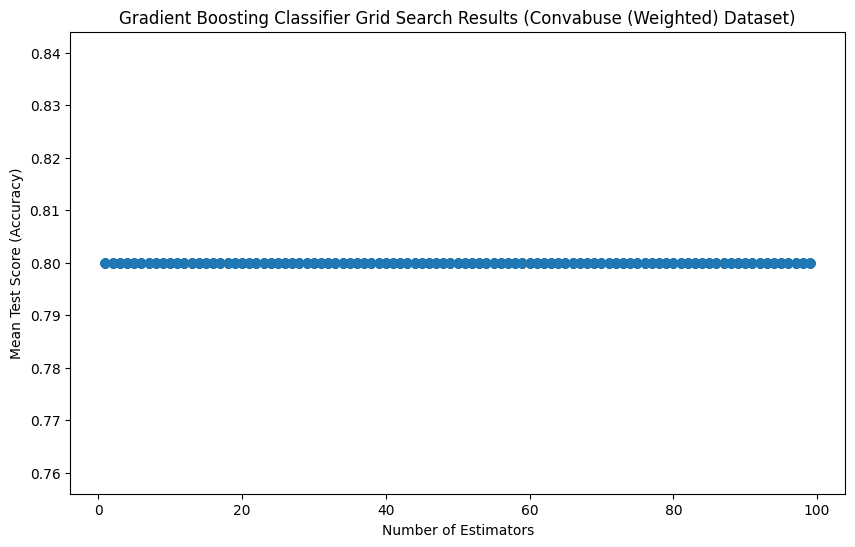

In [41]:
# Plot the grid search results for the Gradient Boosting Classifier on the Convabuse dataset
convabuse_gb_results_accuracy = pd.DataFrame(convabuse_gb_grid_search.cv_results_)
plt.figure(figsize=(10, 6))
plt.plot(convabuse_gb_results_accuracy['param_xgb__n_estimators'], convabuse_gb_results_accuracy['mean_test_score'], marker='o')
plt.title(f'Gradient Boosting Classifier Grid Search Results (Convabuse ({balance}) Dataset)')
plt.xlabel('Number of Estimators')
plt.ylabel('Mean Test Score (Accuracy)')
plt.show()

In [42]:
# Use the best estimator to make predictions on the test set
convabuse_gb_best_estimator = convabuse_gb_grid_search.best_estimator_
convabuse_gb_y_pred = convabuse_gb_best_estimator.predict(convabuse_X_test)

In [43]:
# Calculate the accuracy and f1-score for the Gradient Boosting Classifier on the Convabuse dataset
convabuse_gb_accuracy = accuracy_score(convabuse_y_test, convabuse_gb_y_pred)
convabuse_gb_f1 = f1_score(convabuse_y_test, convabuse_gb_y_pred, average='weighted')

# Print the results
print(f'Convabuse Gradient Boosting Classifier Accuracy: {convabuse_gb_accuracy}')
print(f'Convabuse Gradient Boosting Classifier F1 Score: {convabuse_gb_f1}')

Convabuse Gradient Boosting Classifier Accuracy: 0.8855325914149443
Convabuse Gradient Boosting Classifier F1 Score: 0.8520266948557892


In [44]:
# Print the classification report for the Gradient Boosting Classifier on the Convabuse dataset
print("Classification Report for Convabuse Gradient Boosting Classifier:")
print(classification_report(convabuse_y_test, convabuse_gb_y_pred))

Classification Report for Convabuse Gradient Boosting Classifier:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2013
           1       0.00      0.00      0.00       132
           2       0.76      0.40      0.52       150
           3       0.53      0.90      0.66       173
           4       0.00      0.00      0.00        48

    accuracy                           0.89      2516
   macro avg       0.44      0.46      0.43      2516
weighted avg       0.83      0.89      0.85      2516



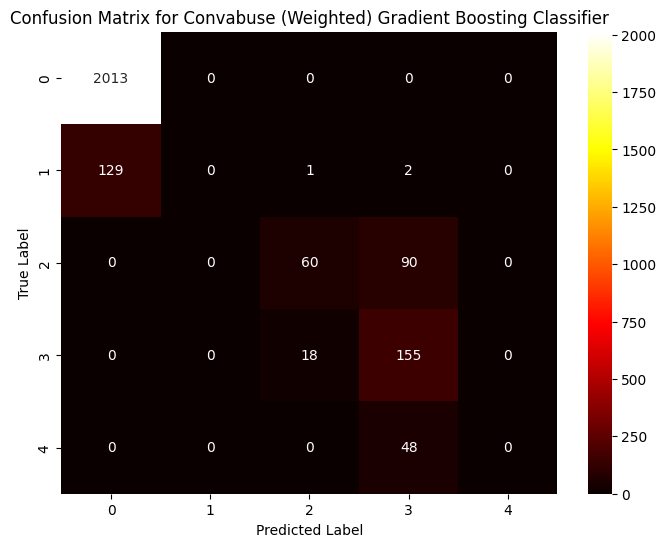

In [45]:
# Plot the confusion matrix for the Gradient Boosting Classifier on the Convabuse dataset
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(convabuse_y_test, convabuse_gb_y_pred), annot=True, fmt='d', cmap='hot')
plt.title(f'Confusion Matrix for Convabuse ({balance}) Gradient Boosting Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Convabuse Importance for Convabuse Gradient Boosting Classifier:
[0.6144965 0.3855035 0.        0.        0.        0.        0.
 0.       ]


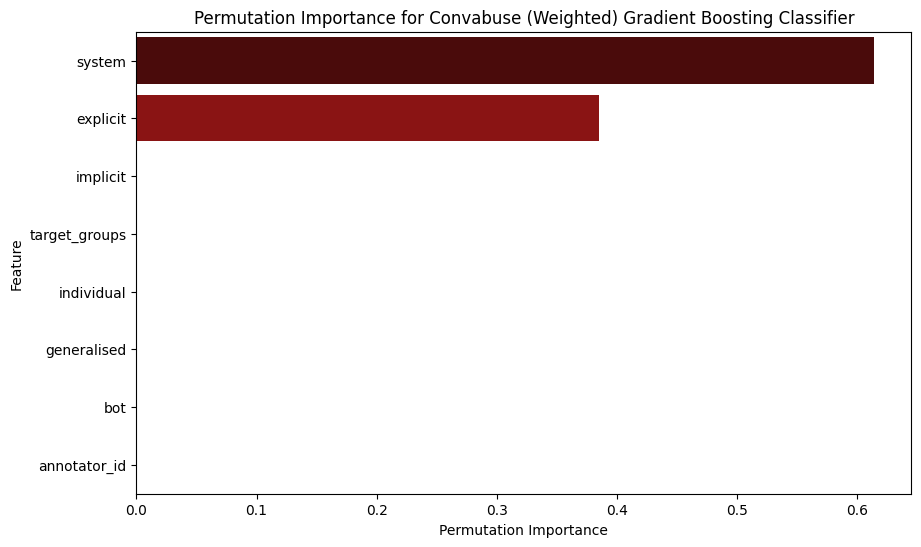

In [46]:
# Calculate feature importance for the Convabuse Gradient Boosting model
convabuse_gb_feature_importance = convabuse_gb_best_estimator.named_steps['xgb'].feature_importances_

# Sort the results by importance mean
convabuse_gb_feature_importance_idx = convabuse_gb_feature_importance.argsort()[::-1]
convabuse_gb_sorted_feature_importance = convabuse_gb_feature_importance[convabuse_gb_feature_importance_idx]

# Save the sorted results as a dictionary
convabuse_gb_sorted_feature_importance_dict = {}
for i, importance in enumerate(convabuse_gb_sorted_feature_importance):
    convabuse_gb_sorted_feature_importance_dict[convabuse_X_numeric.columns[convabuse_gb_feature_importance_idx[i]]] = importance

# Display the results
print("Convabuse Importance for Convabuse Gradient Boosting Classifier:")
print(convabuse_gb_sorted_feature_importance)

# Plot the permutation importances
plt.figure(figsize=(10, 6))
sns.barplot(x=convabuse_gb_sorted_feature_importance, y=convabuse_X_numeric.columns[convabuse_gb_feature_importance_idx], palette="hot")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title(f"Permutation Importance for Convabuse ({balance}) Gradient Boosting Classifier")
plt.show()

In [47]:
# Append details to the results list
gb_classification_results_list.append((
    "Gradient Boosting",
    "Convabuse",
    "NA",
    "NA",
    convabuse_gb_accuracy,
    convabuse_gb_f1,
    0.0,
    convabuse_gb_grid_search.best_params_,
    convabuse_gb_sorted_feature_importance_dict,
    balance
))

In [48]:
gb_classification_results_list

[('Gradient Boosting',
  'Convabuse',
  'NA',
  'NA',
  0.8855325914149443,
  0.8520266948557892,
  0.0,
  {'xgb__learning_rate': np.float64(0.01),
   'xgb__max_depth': 1,
   'xgb__min_child_weight': 10,
   'xgb__n_estimators': 1},
  {'system': np.float32(0.6144965),
   'explicit': np.float32(0.3855035),
   'implicit': np.float32(0.0),
   'target_groups': np.float32(0.0),
   'individual': np.float32(0.0),
   'generalised': np.float32(0.0),
   'bot': np.float32(0.0),
   'annotator_id': np.float32(0.0)},
  'Weighted')]

In [49]:
dghs_X_split_count = int((len(dghs_X_train_sample) / 10))
dghs_X_split_count

32

In [50]:
# Create a pipeline for the XGBoost Classifier for the Dynamically Generated Hate Speech dataset optimized for accuracy
dghs_gb_pipeline = Pipeline([
    ('xgb', XGBClassifier(random_state=42))
])

# Define the parameter grid for GridSearchCV
dghs_param_grid = {
    'xgb__n_estimators': range(1, 100),
    'xgb__learning_rate': np.linspace(0.01, 0.1, 10),
    'xgb__max_depth': range(1, dghs_log2),
    'xgb__min_child_weight': [dghs_X_split_count]
}

# Create a GridSearchCV object
dghs_gb_grid_search = GridSearchCV(
    estimator=dghs_gb_pipeline,
    param_grid=dghs_param_grid,
    scoring='accuracy',
    cv=2
)

In [51]:
# Fit the model
dghs_gb_grid_search.fit(dghs_X_train_sample, dghs_y_train_sample, xgb__sample_weight=dghs_sample_weights_array)

GridSearchCV(cv=2,
             estimator=Pipeline(steps=[('xgb',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      device=None,
                                                      early_stopping_rounds=None,
                                                      enable_categorical=False,
                                                      eval_metric=None,
                                                      feature_types=None,
                                                      feature_weights=None,
                                                      gamma=None,
                                                      grow_policy=None,
                                                      importance_type=None,
                                                      inte...
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             param_grid={'xgb__learning_rate': array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ]),
                         'xgb__max_depth': range(1, 9),
                         'xgb__min_child_weight': [32],
                         'xgb__n_estimators': range(1, 100)},
             scoring='accuracy')

In [52]:
# Get the best parameters
dghs_gb_best_params = dghs_gb_grid_search.best_params_

# Get the best score
dghs_gb_best_score = dghs_gb_grid_search.best_score_

# Print
print("Best Parameters:", dghs_gb_best_params)
print("Best Score:", dghs_gb_best_score)

Best Parameters: {'xgb__learning_rate': np.float64(0.01), 'xgb__max_depth': 1, 'xgb__min_child_weight': 32, 'xgb__n_estimators': 1}
Best Score: 0.498634595241658


In [53]:
# Pickle the model
with open(f'{pickle_path}dghs_xgb_model_{name}.pkl', 'wb') as f:
    pickle.dump(dghs_gb_grid_search, f)

In [54]:
# Import the model
with open(f'{pickle_path}dghs_xgb_model_{name}.pkl', 'rb') as f:
    dghs_gb_model = pickle.load(f)

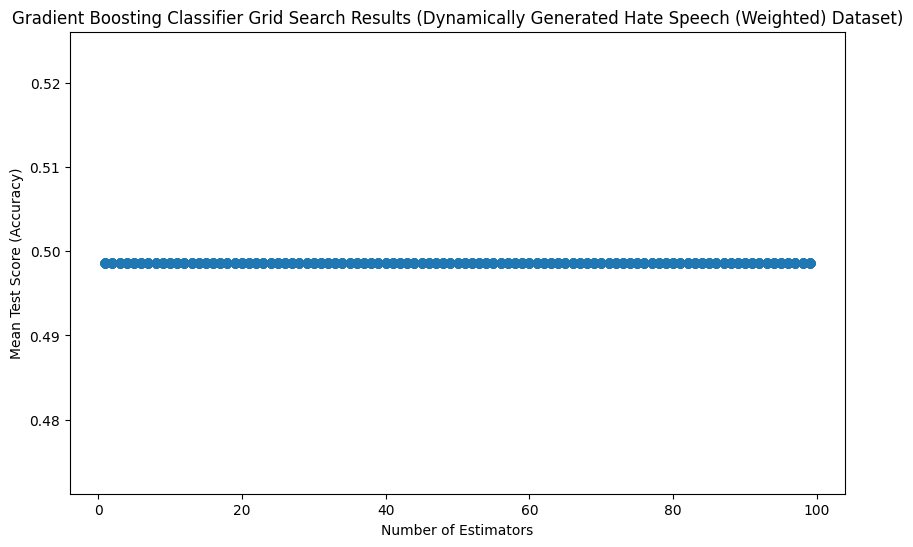

In [55]:
# Plot the grid search results for the Gradient Boosting Classifier on the Dynamically Generated Hate Speech dataset
dghs_gb_results_accuracy = pd.DataFrame(dghs_gb_grid_search.cv_results_)
plt.figure(figsize=(10, 6))
plt.plot(dghs_gb_results_accuracy['param_xgb__n_estimators'], dghs_gb_results_accuracy['mean_test_score'], marker='o')
plt.title(f'Gradient Boosting Classifier Grid Search Results (Dynamically Generated Hate Speech ({balance}) Dataset)')
plt.xlabel('Number of Estimators')
plt.ylabel('Mean Test Score (Accuracy)')
plt.show()

In [56]:
# Use the best estimator to make predictions on the test set
dghs_gb_best_estimator = dghs_gb_grid_search.best_estimator_
dghs_gb_y_pred = dghs_gb_best_estimator.predict(dghs_X_test)

In [57]:
# Calculate the accuracy and f1-score for the Gradient Boosting Classifier on the Dynamically Generated Hate Speech dataset
dghs_gb_accuracy = accuracy_score(dghs_y_test, dghs_gb_y_pred)
dghs_gb_f1 = f1_score(dghs_y_test, dghs_gb_y_pred, average='weighted')

In [58]:
# Print the results
print(f'Dynamically Generated Hate Speech Gradient Boosting Classifier Accuracy: {dghs_gb_accuracy}')
print(f'Dynamically Generated Hate Speech Gradient Boosting Classifier F1 Score: {dghs_gb_f1}')

Dynamically Generated Hate Speech Gradient Boosting Classifier Accuracy: 0.5350512945774304
Dynamically Generated Hate Speech Gradient Boosting Classifier F1 Score: 0.5181276221763418


In [59]:
# Print the classification report for the Gradient Boosting Classifier on the Dynamically Generated Hate Speech dataset
print("Classification Report for Dynamically Generated Hate Speech Gradient Boosting Classifier:")
print(classification_report(dghs_y_test, dghs_gb_y_pred))

Classification Report for Dynamically Generated Hate Speech Gradient Boosting Classifier:
              precision    recall  f1-score   support

         0.0       0.50      0.33      0.40      3794
         1.0       0.55      0.71      0.62      4394

    accuracy                           0.54      8188
   macro avg       0.52      0.52      0.51      8188
weighted avg       0.53      0.54      0.52      8188



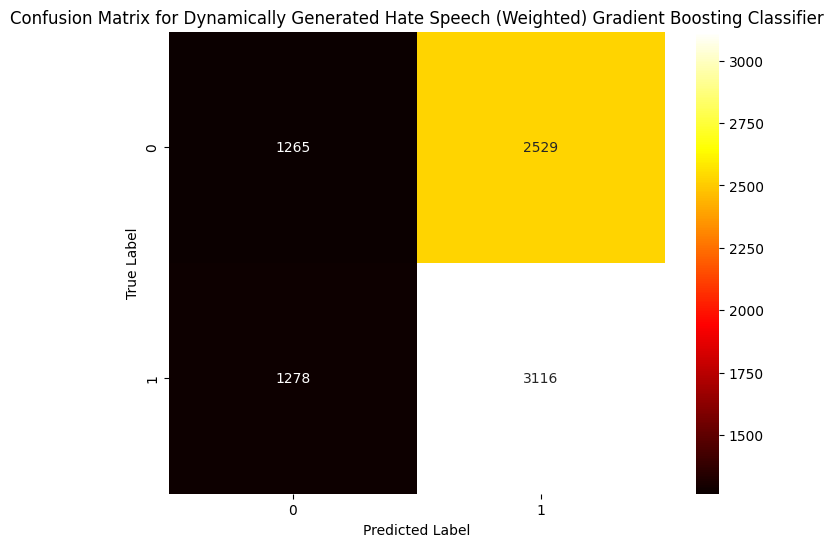

In [60]:
# Plot the confusion matrix for the Gradient Boosting Classifier on the Dynamically Generated Hate Speech dataset
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(dghs_y_test, dghs_gb_y_pred), annot=True, fmt='d', cmap='hot')
plt.title(f'Confusion Matrix for Dynamically Generated Hate Speech ({balance}) Gradient Boosting Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


Permutation Importance for DGHS Gradient Boosting Classifier:
[0. 1. 0. 0.]


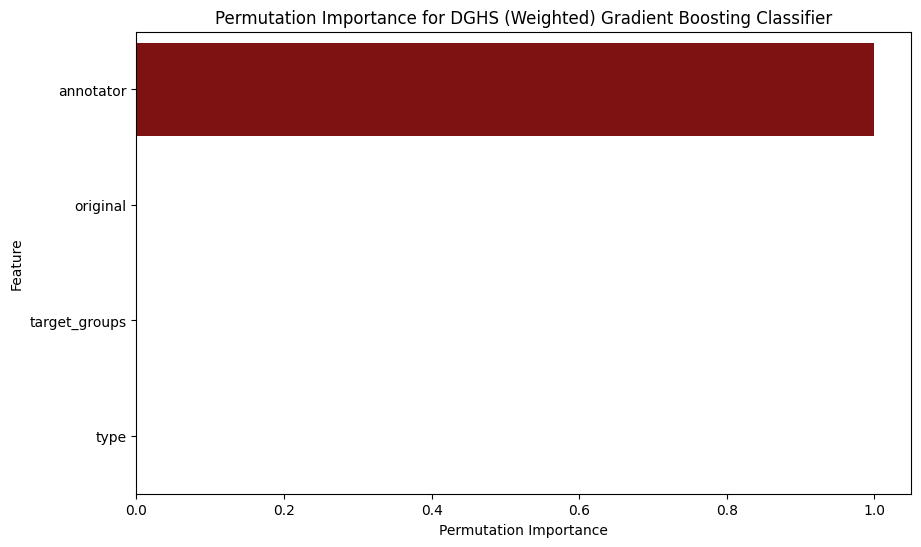

In [61]:
# Calculate feature importance for the DGHS Gradient Boosting model
dghs_gb_feature_importance = dghs_gb_best_estimator.named_steps['xgb'].feature_importances_

# Sort the results by importance mean
dghs_gb_feature_importance_idx = dghs_gb_feature_importance.argsort()[::-1]
dghs_gb_sorted_feature_importance = dghs_gb_feature_importance[dghs_gb_feature_importance_idx]  # Sort the results by importance mean

# Save the sorted results as a dictionary
dghs_gb_sorted_feature_importance_dict = {}
for i, importance in enumerate(dghs_gb_sorted_feature_importance):
    dghs_gb_sorted_feature_importance_dict[dghs_X_numeric.columns[dghs_gb_feature_importance_idx[i]]] = importance

# Display the results
print("Permutation Importance for DGHS Gradient Boosting Classifier:")
print(dghs_gb_feature_importance)

# Plot the permutation importances
plt.figure(figsize=(10, 6))
sns.barplot(x=dghs_gb_sorted_feature_importance, y=dghs_X_numeric.columns[dghs_gb_feature_importance_idx], palette="hot")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title(f"Permutation Importance for DGHS ({balance}) Gradient Boosting Classifier")
plt.show()

In [62]:
# Append details to the results list
gb_classification_results_list.append((
    "Gradient Boosting",
    "Dynamically Generated Hate Speech",
    "NA",
    "NA",
    dghs_gb_accuracy,
    dghs_gb_f1,
    0.0,
    dghs_gb_grid_search.best_params_,
    dghs_gb_sorted_feature_importance_dict,
    balance
))

In [63]:
gb_classification_results_list

[('Gradient Boosting',
  'Convabuse',
  'NA',
  'NA',
  0.8855325914149443,
  0.8520266948557892,
  0.0,
  {'xgb__learning_rate': np.float64(0.01),
   'xgb__max_depth': 1,
   'xgb__min_child_weight': 10,
   'xgb__n_estimators': 1},
  {'system': np.float32(0.6144965),
   'explicit': np.float32(0.3855035),
   'implicit': np.float32(0.0),
   'target_groups': np.float32(0.0),
   'individual': np.float32(0.0),
   'generalised': np.float32(0.0),
   'bot': np.float32(0.0),
   'annotator_id': np.float32(0.0)},
  'Weighted'),
 ('Gradient Boosting',
  'Dynamically Generated Hate Speech',
  'NA',
  'NA',
  0.5350512945774304,
  0.5181276221763418,
  0.0,
  {'xgb__learning_rate': np.float64(0.01),
   'xgb__max_depth': 1,
   'xgb__min_child_weight': 32,
   'xgb__n_estimators': 1},
  {'annotator': np.float32(1.0),
   'original': np.float32(0.0),
   'target_groups': np.float32(0.0),
   'type': np.float32(0.0)},
  'Weighted')]

In [64]:
oaa_X_split_count = int((len(oaa_X_train_sample) / 10))
oaa_X_split_count

1

In [65]:
# Create a pipeline for the XGBoost Regressor for the Online Abusive Attacks dataset optimized for accuracy
oaa_gb_pipeline = Pipeline([
    ('xgb', XGBClassifier())  # keeps things fast/stable
])

# Define the parameter grid for GridSearchCV
oaa_param_grid = {
    'xgb__n_estimators': range(1, 100),
    'xgb__learning_rate': np.linspace(0.01, 0.1, 10),
    'xgb__max_depth': range(1, online_abusive_attacks_log2),
    'xgb__min_child_weight': [oaa_X_split_count] # Use min_child_weight for XGBoost
}

# Create a GridSearchCV object
oaa_gb_grid_search = GridSearchCV(
    estimator=oaa_gb_pipeline,
    param_grid=oaa_param_grid,
    scoring='accuracy',
    cv=2
)

In [66]:
# Create a pipeline for the XGBoost Regressor for the Online Abusive Attacks dataset optimized for accuracy
# This redefines the pipeline with the corrected parameters

# Apply OrdinalEncoder to ensure contiguous labels for XGBoost
# Using a consistent encoder for both train and test samples
oaa_encoder = OrdinalEncoder(categories=[sorted(online_abusive_attacks_y_sample.unique())])

# Transform the training and testing y samples
oaa_y_train_sample_encoded = oaa_encoder.fit_transform(oaa_y_train_sample.to_frame())
oaa_y_test_sample_encoded = oaa_encoder.transform(oaa_y_test_sample.to_frame())

# Get the number of classes from the encoded data
num_classes_oaa = len(oaa_encoder.categories_[0])

oaa_gb_pipeline = Pipeline([
    ('xgb', XGBClassifier(objective='multi:softmax', num_class=num_classes_oaa, random_state=42))
])

# Define the parameter grid for GridSearchCV (copying from previous cell to ensure it's re-run)
oaa_param_grid = {
    'xgb__n_estimators': range(1, 100),
    'xgb__learning_rate': np.linspace(0.01, 0.1, 10),
    'xgb__max_depth': range(1, online_abusive_attacks_log2),
    'xgb__min_child_weight': [oaa_X_split_count] # Use min_child_weight for XGBoost
}

# Create a GridSearchCV object (copying from previous cell to ensure it's re-run)
oaa_gb_grid_search = GridSearchCV(
    estimator=oaa_gb_pipeline,
    param_grid=oaa_param_grid,
    scoring='accuracy',
    cv=2
)

# Fit the model using the encoded labels
oaa_gb_grid_search.fit(oaa_X_train_sample, oaa_y_train_sample_encoded.ravel(), xgb__sample_weight=oaa_sample_weights_array)

GridSearchCV(cv=2,
             estimator=Pipeline(steps=[('xgb',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      device=None,
                                                      early_stopping_rounds=None,
                                                      enable_categorical=False,
                                                      eval_metric=None,
                                                      feature_types=None,
                                                      feature_weights=None,
                                                      gamma=None,
                                                      grow_policy=None,
                                                      importance_type=None,
                                                      inte...
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None, num_class=4, ...))]),
             param_grid={'xgb__learning_rate': array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ]),
                         'xgb__max_depth': range(1, 5),
                         'xgb__min_child_weight': [1],
                         'xgb__n_estimators': range(1, 100)},
             scoring='accuracy')

In [67]:
# Get the best parameters
oaa_gb_best_params = oaa_gb_grid_search.best_params_

# Get the best score
oaa_gb_best_score = oaa_gb_grid_search.best_score_

# Print
print("Best Parameters:", oaa_gb_best_params)
print("Best Score:", oaa_gb_best_score)

Best Parameters: {'xgb__learning_rate': np.float64(0.01), 'xgb__max_depth': 1, 'xgb__min_child_weight': 1, 'xgb__n_estimators': 1}
Best Score: nan


In [68]:
# Pickle the model
with open(f'{pickle_path}oaa_xgb_model_{name}.pkl', 'wb') as f:
    pickle.dump(oaa_gb_grid_search, f)

In [69]:
# Import the model
with open(f'{pickle_path}oaa_xgb_model_{name}.pkl', 'rb') as f:
    oaa_gb_grid_search = pickle.load(f)

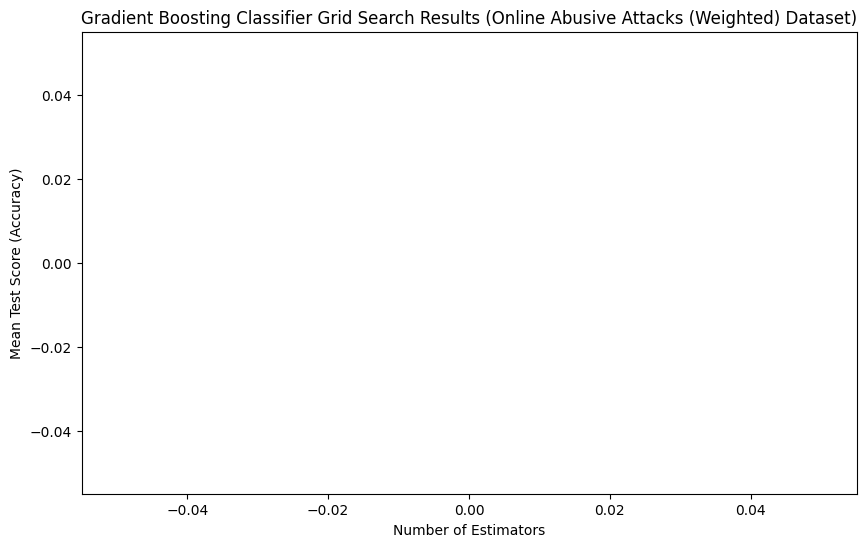

In [70]:
# Plot the grid search results for the Gradient Boosting Classifier on the Online Abusive Attacks dataset
oaa_gb_results_accuracy = pd.DataFrame(oaa_gb_grid_search.cv_results_)
plt.figure(figsize=(10, 6))
plt.plot(oaa_gb_results_accuracy['param_xgb__n_estimators'], oaa_gb_results_accuracy['mean_test_score'], marker='o')
plt.title(f'Gradient Boosting Classifier Grid Search Results (Online Abusive Attacks ({balance}) Dataset)')
plt.xlabel('Number of Estimators')
plt.ylabel('Mean Test Score (Accuracy)')
plt.show()

In [71]:
# Use the best estimator to make predictions on the test set
oaa_gb_best_estimator = oaa_gb_grid_search.best_estimator_
oaa_gb_y_pred = oaa_gb_best_estimator.predict(oaa_X_test)

In [72]:
# Calculate the RMSE and R2 score for the Gradient Boosting Classifier on the Online Abusive Attacks dataset
oaa_gb_accuracy = accuracy_score(oaa_y_test, oaa_gb_y_pred)
oaa_gb_f1 = f1_score(oaa_y_test, oaa_gb_y_pred, average='weighted')

# Print the results
print(f'Online Abusive Attacks Gradient Boosting Classifier Accuracy: {oaa_gb_accuracy}')
print(f'Online Abusive Attacks Gradient Boosting Classifier F1 Score: {oaa_gb_f1}')

Online Abusive Attacks Gradient Boosting Classifier Accuracy: 0.7580993520518359
Online Abusive Attacks Gradient Boosting Classifier F1 Score: 0.7295041423806717


In [73]:
# Print the classification report for the Gradient Boosting Classifier on the Dynamically Generated Hate Speech dataset
print("Classification Report for Online Abusive Attacks Gradient Boosting Classifier:")
print(classification_report(oaa_y_test, oaa_gb_y_pred))

Classification Report for Online Abusive Attacks Gradient Boosting Classifier:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86       221
           1       0.94      0.58      0.72       177
           2       0.52      0.82      0.64        33
           3       0.00      0.00      0.00        15
           4       0.00      0.00      0.00        17

    accuracy                           0.76       463
   macro avg       0.44      0.48      0.44       463
weighted avg       0.76      0.76      0.73       463



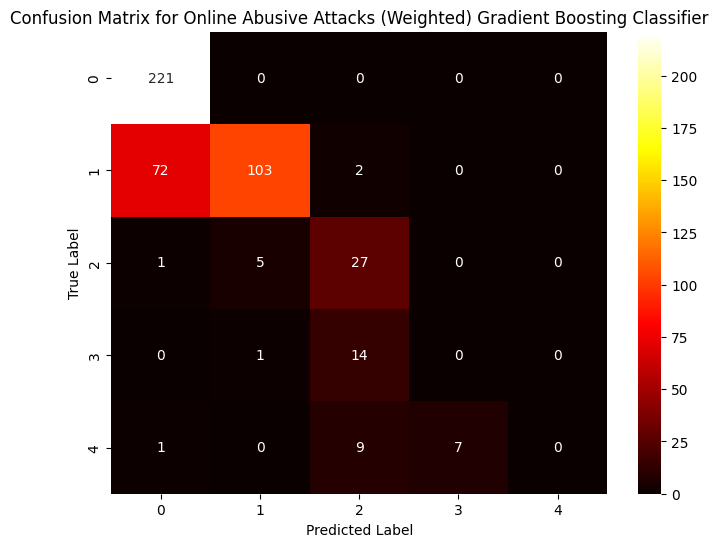

In [74]:
# Plot the confusion matrix for the Gradient Boosting Classifier on the Dynamically Generated Hate Speech dataset
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(oaa_y_test, oaa_gb_y_pred), annot=True, fmt='d', cmap='hot')
plt.title(f'Confusion Matrix for Online Abusive Attacks ({balance}) Gradient Boosting Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Feature Importance for Online Abusive Attacks Gradient Boosting Classifier:
[1. 0.]


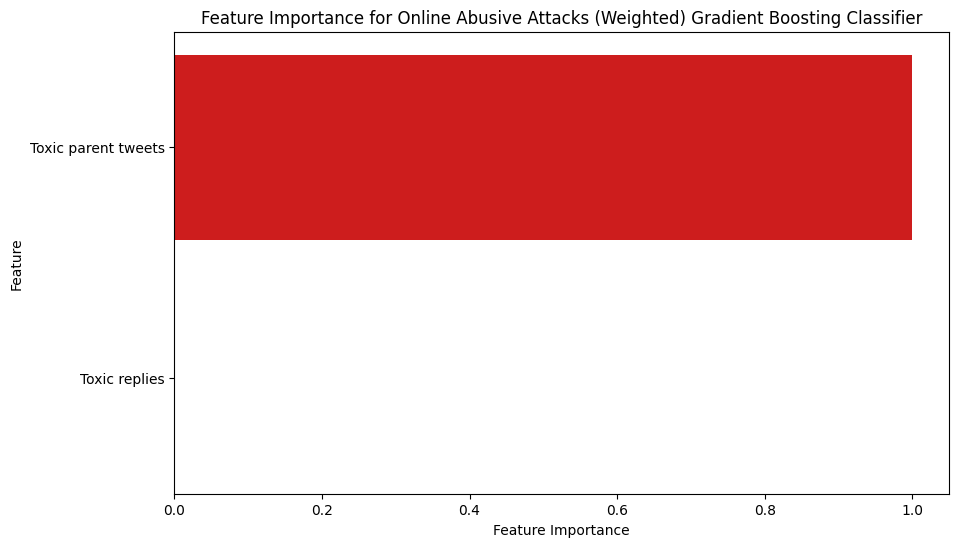

In [75]:
# Calculate feature importance for the model
oaa_gb_feature_importance = oaa_gb_best_estimator.named_steps['xgb'].feature_importances_

# Sort the results by importance mean
oaa_gb_feature_importance_idx = oaa_gb_feature_importance.argsort()[::-1]
oaa_gb_sorted_feature_importance = oaa_gb_feature_importance[oaa_gb_feature_importance_idx]

# Save the sorted results as a dictionary
oaa_gb_sorted_feature_importance_dict = {}
for i, importance in enumerate(oaa_gb_sorted_feature_importance):
    oaa_gb_sorted_feature_importance_dict[online_abusive_attacks_X_numeric.columns[oaa_gb_feature_importance_idx[i]]] = importance

# Display the results
print("Feature Importance for Online Abusive Attacks Gradient Boosting Classifier:")
print(oaa_gb_feature_importance)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=oaa_gb_sorted_feature_importance[:10], y=online_abusive_attacks_X_numeric.columns[oaa_gb_feature_importance_idx][:10], palette="hot")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title(f"Feature Importance for Online Abusive Attacks ({balance}) Gradient Boosting Classifier")
plt.show()

In [76]:
# Append details to the results list
gb_classification_results_list.append((
    "Gradient Boosting",
    "Online Abusive Attacks",
    "NA",
    "NA",
    oaa_gb_accuracy,
    oaa_gb_f1,
    oaa_gb_grid_search.best_params_,
    oaa_gb_sorted_feature_importance_dict,
    balance
))

In [77]:
gb_classification_results_list

[('Gradient Boosting',
  'Convabuse',
  'NA',
  'NA',
  0.8855325914149443,
  0.8520266948557892,
  0.0,
  {'xgb__learning_rate': np.float64(0.01),
   'xgb__max_depth': 1,
   'xgb__min_child_weight': 10,
   'xgb__n_estimators': 1},
  {'system': np.float32(0.6144965),
   'explicit': np.float32(0.3855035),
   'implicit': np.float32(0.0),
   'target_groups': np.float32(0.0),
   'individual': np.float32(0.0),
   'generalised': np.float32(0.0),
   'bot': np.float32(0.0),
   'annotator_id': np.float32(0.0)},
  'Weighted'),
 ('Gradient Boosting',
  'Dynamically Generated Hate Speech',
  'NA',
  'NA',
  0.5350512945774304,
  0.5181276221763418,
  0.0,
  {'xgb__learning_rate': np.float64(0.01),
   'xgb__max_depth': 1,
   'xgb__min_child_weight': 32,
   'xgb__n_estimators': 1},
  {'annotator': np.float32(1.0),
   'original': np.float32(0.0),
   'target_groups': np.float32(0.0),
   'type': np.float32(0.0)},
  'Weighted'),
 ('Gradient Boosting',
  'Online Abusive Attacks',
  'NA',
  'NA',
  0.7580

In [78]:
us2020hs_X_split_count = int((len(us2020hs_X_train_sample) / 10))
us2020hs_X_split_count

2

In [79]:
# Create a pipeline for the XGBoost Classifier for the US Elections 2020 Hate Speech dataset optimized for accuracy
from xgboost import XGBClassifier

us2020hs_gb_pipeline = Pipeline([
    ('xgb', XGBClassifier(random_state=42))
])

# Define the parameter grid for GridSearchCV
us2020hs_param_grid = {
    'xgb__n_estimators': range(1, 100),
    'xgb__learning_rate': np.linspace(0.01, 0.1, 10),
    'xgb__max_depth': range(1, us2020hs_log2),
    'xgb__min_child_weight': [us2020hs_X_split_count] # Use min_child_weight for XGBoost
}

# Create a GridSearchCV object
us2020hs_gb_grid_search = GridSearchCV(
    estimator=us2020hs_gb_pipeline,
    param_grid=us2020hs_param_grid,
    scoring='accuracy',
    cv=2,
    n_jobs=-1,
    verbose=1
)

In [80]:
# Fit the model
us2020hs_gb_grid_search.fit(us2020hs_X_train_sample, us2020hs_y_train_sample, xgb__sample_weight=us2020hs_sample_weights_array)

Fitting 2 folds for each of 3960 candidates, totalling 7920 fits


GridSearchCV(cv=2,
             estimator=Pipeline(steps=[('xgb',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      device=None,
                                                      early_stopping_rounds=None,
                                                      enable_categorical=False,
                                                      eval_metric=None,
                                                      feature_types=None,
                                                      feature_weights=None,
                                                      gamma=None,
                                                      grow_policy=None,
                                                      importance_type=None,
                                                      inte...
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'xgb__learning_rate': array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ]),
                         'xgb__max_depth': range(1, 5),
                         'xgb__min_child_weight': [2],
                         'xgb__n_estimators': range(1, 100)},
             scoring='accuracy', verbose=1)

In [81]:
# Get the best parameters
us2020hs_gb_best_params = us2020hs_gb_grid_search.best_params_

# Get the best score
us2020hs_gb_best_score = us2020hs_gb_grid_search.best_score_

# Print
print("Best Parameters:", us2020hs_gb_best_params)
print("Best Score:", us2020hs_gb_best_score)

Best Parameters: {'xgb__learning_rate': np.float64(0.01), 'xgb__max_depth': 1, 'xgb__min_child_weight': 2, 'xgb__n_estimators': 1}
Best Score: 0.45833333333333337


In [82]:
# Pickle the model
with open(f'{pickle_path}us2020hs_xgb_model_{name}.pkl', 'wb') as f:
    pickle.dump(us2020hs_gb_grid_search, f)

In [83]:
# Import the model
with open(f'{pickle_path}us2020hs_xgb_model_{name}.pkl', 'rb') as f:
    us2020hs_gb_model = pickle.load(f)

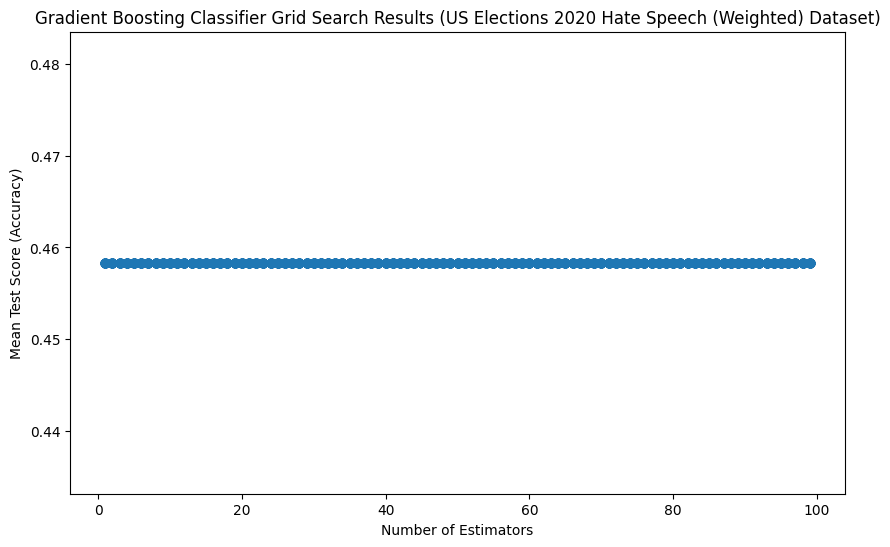

In [84]:
# Plot the grid search results for the Gradient Boosting Classifier on the US Elections 2020 Hate Speech dataset
us2020hs_gb_results_accuracy = pd.DataFrame(us2020hs_gb_grid_search.cv_results_)
plt.figure(figsize=(10, 6))
plt.plot(us2020hs_gb_results_accuracy['param_xgb__n_estimators'], us2020hs_gb_results_accuracy['mean_test_score'], marker='o')
plt.title(f'Gradient Boosting Classifier Grid Search Results (US Elections 2020 Hate Speech ({balance}) Dataset)')
plt.xlabel('Number of Estimators')
plt.ylabel('Mean Test Score (Accuracy)')
plt.show()

In [85]:
# Use the best estimator to make predictions on the test set
us2020hs_gb_best_estimator = us2020hs_gb_grid_search.best_estimator_
us2020hs_gb_y_pred = us2020hs_gb_best_estimator.predict(us2020hs_X_test)

In [86]:
# Calculate the accuracy and f1-score for the Gradient Boosting Classifier on the US Elections 2020 Hate Speech dataset
us2020hs_gb_accuracy = accuracy_score(us2020hs_y_test, us2020hs_gb_y_pred)
us2020hs_gb_f1 = f1_score(us2020hs_y_test, us2020hs_gb_y_pred, average='weighted')

# Print the results
print(f'US Elections 2020 Hate Speech Gradient Boosting Classifier Accuracy: {us2020hs_gb_accuracy}')
print(f'US Elections 2020 Hate Speech Gradient Boosting Classifier F1 Score: {us2020hs_gb_f1}')

US Elections 2020 Hate Speech Gradient Boosting Classifier Accuracy: 0.6010016694490818
US Elections 2020 Hate Speech Gradient Boosting Classifier F1 Score: 0.6680592852153668


In [87]:
# Print the classification report for the Gradient Boosting Classifier on the US Elections 2020 Hate Speech dataset
print("Classification Report for US Elections 2020 Hate Speech Gradient Boosting Classifier:")
print(classification_report(us2020hs_y_test, us2020hs_gb_y_pred))

Classification Report for US Elections 2020 Hate Speech Gradient Boosting Classifier:
              precision    recall  f1-score   support

           0       0.86      0.66      0.74       529
           1       0.06      0.17      0.09        70

    accuracy                           0.60       599
   macro avg       0.46      0.41      0.42       599
weighted avg       0.76      0.60      0.67       599



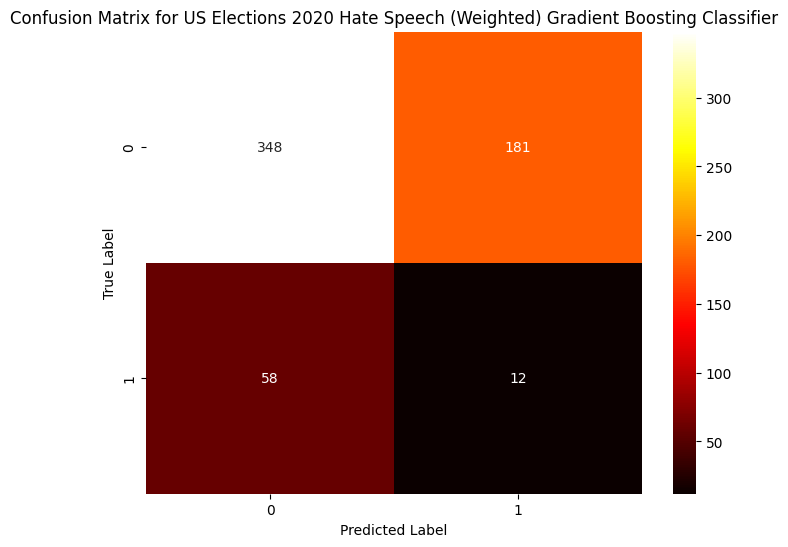

In [88]:
# Plot the confusion matrix for the Gradient Boosting Classifier on the US Elections 2020 Hate Speech dataset
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(us2020hs_y_test, us2020hs_gb_y_pred), annot=True, fmt='d', cmap='hot')
plt.title(f'Confusion Matrix for US Elections 2020 Hate Speech ({balance}) Gradient Boosting Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Feature Importance for US Elections 2020 Hate Speech Gradient Boosting Classifier:
[1. 0. 0.]


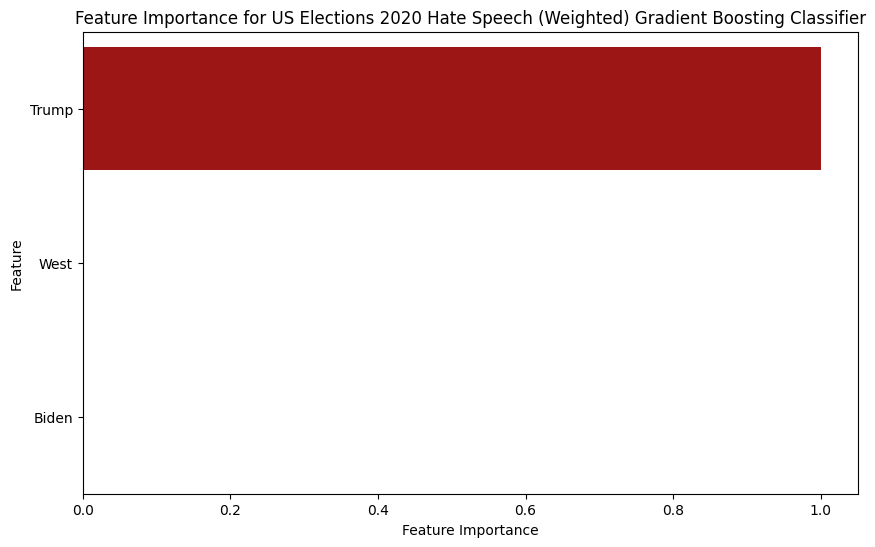

In [89]:
# Calculate feature importance for the model
us2020hs_gb_feature_importance = us2020hs_gb_best_estimator.named_steps['xgb'].feature_importances_

# Sort the results by importance mean
us2020hs_gb_feature_importance_idx = us2020hs_gb_feature_importance.argsort()[::-1]
us2020hs_gb_sorted_feature_importance = us2020hs_gb_feature_importance[us2020hs_gb_feature_importance_idx]  # Sort the results by importance mean

# Save the sorted results as a dictionary
us2020hs_gb_sorted_feature_importance_dict = {}
for i, importance in enumerate(us2020hs_gb_sorted_feature_importance):
    us2020hs_gb_sorted_feature_importance_dict[us2020hs_X_numeric.columns[us2020hs_gb_feature_importance_idx[i]]] = importance

# Display the results
print("Feature Importance for US Elections 2020 Hate Speech Gradient Boosting Classifier:")
print(us2020hs_gb_feature_importance)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=us2020hs_gb_sorted_feature_importance[:10], y=us2020hs_X_numeric.columns[us2020hs_gb_feature_importance_idx[:10]], palette="hot")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title(f"Feature Importance for US Elections 2020 Hate Speech ({balance}) Gradient Boosting Classifier")
plt.show()

In [90]:
# Append details to the results list
gb_classification_results_list.append((
    "Gradient Boosting",
    "US Elections 2020 Hate Speech",
    "NA",
    "NA",
    us2020hs_gb_accuracy,
    us2020hs_gb_f1,
    0.0,
    us2020hs_gb_grid_search.best_params_,
    us2020hs_gb_sorted_feature_importance_dict,
    balance
))

In [91]:
mlma_hate_speech_X_sample_split_count = int((len(mlma_hate_speech_X_train_sample) / 10))
mlma_hate_speech_X_sample_split_count

14

In [92]:
# Create a pipeline for the XGBoost Classifier for the MLMA Hate Speech dataset optimized for accuracy
from xgboost import XGBClassifier

mlma_hate_speech_gb_pipeline = Pipeline([
    ('xgb', XGBClassifier())
])

# Define the parameter grid for GridSearchCV
mlma_hate_speech_param_grid = {
    'xgb__n_estimators': range(1, 100),
    'xgb__learning_rate': np.linspace(0.01, 0.1, 10),
    'xgb__max_depth': range(1, mlma_hate_speech_log2),
    'xgb__min_child_weight': [mlma_hate_speech_X_sample_split_count]
}

# Create a GridSearchCV object
mlma_hate_speech_gb_grid_search = GridSearchCV(
    estimator=mlma_hate_speech_gb_pipeline,
    param_grid=mlma_hate_speech_param_grid,
    scoring='accuracy',
    cv=2,
    n_jobs=-1,
    verbose=1
)

In [93]:
# Fit the model
mlma_hate_speech_gb_grid_search.fit(mlma_hate_speech_X_train_sample, mlma_hate_speech_y_train_sample, xgb__sample_weight=mlma_hate_speech_sample_weights_array)

Fitting 2 folds for each of 6930 candidates, totalling 13860 fits


GridSearchCV(cv=2,
             estimator=Pipeline(steps=[('xgb',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      device=None,
                                                      early_stopping_rounds=None,
                                                      enable_categorical=False,
                                                      eval_metric=None,
                                                      feature_types=None,
                                                      feature_weights=None,
                                                      gamma=None,
                                                      grow_policy=None,
                                                      importance_type=None,
                                                      inte...
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'xgb__learning_rate': array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ]),
                         'xgb__max_depth': range(1, 8),
                         'xgb__min_child_weight': [14],
                         'xgb__n_estimators': range(1, 100)},
             scoring='accuracy', verbose=1)

In [94]:
# Get the best parameters
mlma_hate_speech_gb_best_params = mlma_hate_speech_gb_grid_search.best_params_

# Get the best score
mlma_hate_speech_gb_best_score = mlma_hate_speech_gb_grid_search.best_score_

# Print
print("Best Parameters:", mlma_hate_speech_gb_best_params)
print("Best Score:", mlma_hate_speech_gb_best_score)

Best Parameters: {'xgb__learning_rate': np.float64(0.020000000000000004), 'xgb__max_depth': 1, 'xgb__min_child_weight': 14, 'xgb__n_estimators': 60}
Best Score: 0.15405405405405406


In [95]:
# Pickle the model
with open(f'{pickle_path}mlma_hate_speech_xgb_model_{name}.pkl', 'wb') as f:
    pickle.dump(mlma_hate_speech_gb_grid_search, f)

In [96]:
# Import the model
with open(f'{pickle_path}mlma_hate_speech_xgb_model_{name}.pkl', 'rb') as f:
    mlma_hate_speech_gb_model = pickle.load(f)

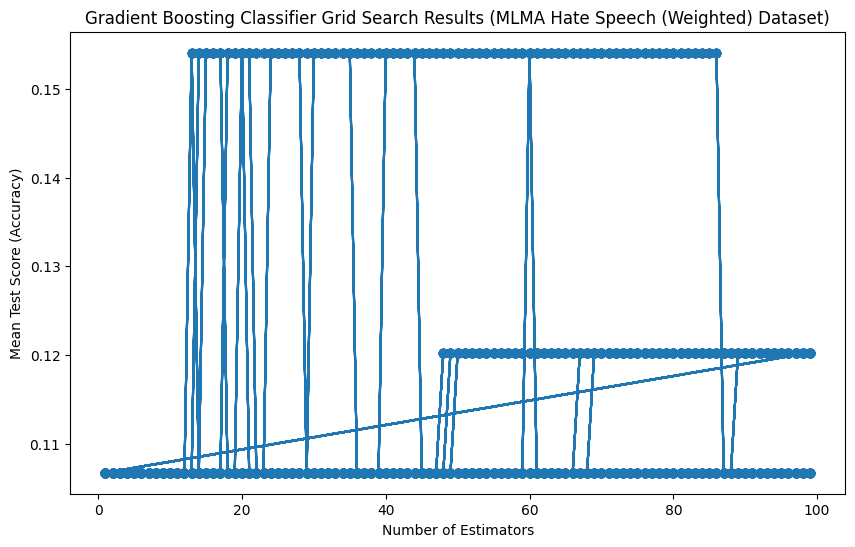

In [97]:
# Plot the grid search results for the Gradient Boosting Classifier on the MLMA Hate Speech dataset
mlma_hate_speech_gb_results_accuracy = pd.DataFrame(mlma_hate_speech_gb_grid_search.cv_results_)
plt.figure(figsize=(10, 6))
plt.plot(mlma_hate_speech_gb_results_accuracy['param_xgb__n_estimators'], mlma_hate_speech_gb_results_accuracy['mean_test_score'], marker='o')
plt.title(f'Gradient Boosting Classifier Grid Search Results (MLMA Hate Speech ({balance}) Dataset)')
plt.xlabel('Number of Estimators')
plt.ylabel('Mean Test Score (Accuracy)')
plt.show()

In [98]:
# Use the best estimator to make predictions on the test set
mlma_hate_speech_gb_best_estimator = mlma_hate_speech_gb_grid_search.best_estimator_
mlma_hate_speech_gb_y_pred = mlma_hate_speech_gb_best_estimator.predict(mlma_hate_speech_X_test)

In [99]:
# Calculate the accuracy and f1-score for the Gradient Boosting Classifier on the MLMA Hate Speech dataset
mlma_hate_speech_gb_accuracy = accuracy_score(mlma_hate_speech_y_test, mlma_hate_speech_gb_y_pred)
mlma_hate_speech_gb_f1 = f1_score(mlma_hate_speech_y_test, mlma_hate_speech_gb_y_pred, average='weighted')

# Print the results
print(f'MLMA Hate Speech Gradient Boosting Classifier Accuracy: {mlma_hate_speech_gb_accuracy}')
print(f'MLMA Hate Speech Gradient Boosting Classifier F1 Score: {mlma_hate_speech_gb_f1}')

MLMA Hate Speech Gradient Boosting Classifier Accuracy: 0.1827438370846731
MLMA Hate Speech Gradient Boosting Classifier F1 Score: 0.12067639108126715


In [100]:
# Print the classification report for the Gradient Boosting Classifier on the MLMA Hate Speech dataset
print("Classification Report for MLMA Hate Speech Gradient Boosting Classifier:")
print(classification_report(mlma_hate_speech_y_test, mlma_hate_speech_gb_y_pred))

Classification Report for MLMA Hate Speech Gradient Boosting Classifier:
              precision    recall  f1-score   support

           0       0.30      0.30      0.30       837
           1       0.00      0.00      0.00      2168
           2       0.20      0.62      0.31       629
           3       0.04      0.38      0.07        98

    accuracy                           0.18      3732
   macro avg       0.13      0.33      0.17      3732
weighted avg       0.10      0.18      0.12      3732



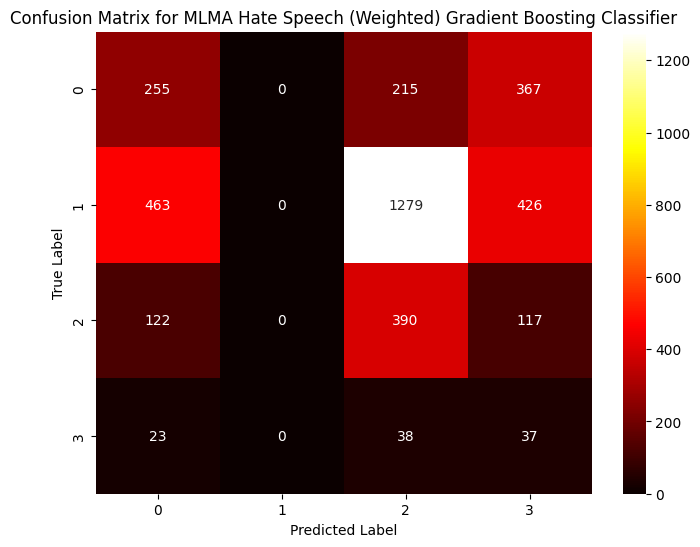

In [101]:
# Plot the confusion matrix for the Gradient Boosting Classifier on the MLMA Hate Speech dataset
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(mlma_hate_speech_y_test, mlma_hate_speech_gb_y_pred), annot=True, fmt='d', cmap='hot')
plt.title(f'Confusion Matrix for MLMA Hate Speech ({balance}) Gradient Boosting Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Feature Importance for MLMA Hate Speech Gradient Boosting Classifier:
[0.6580093  0.         0.34199074 0.        ]


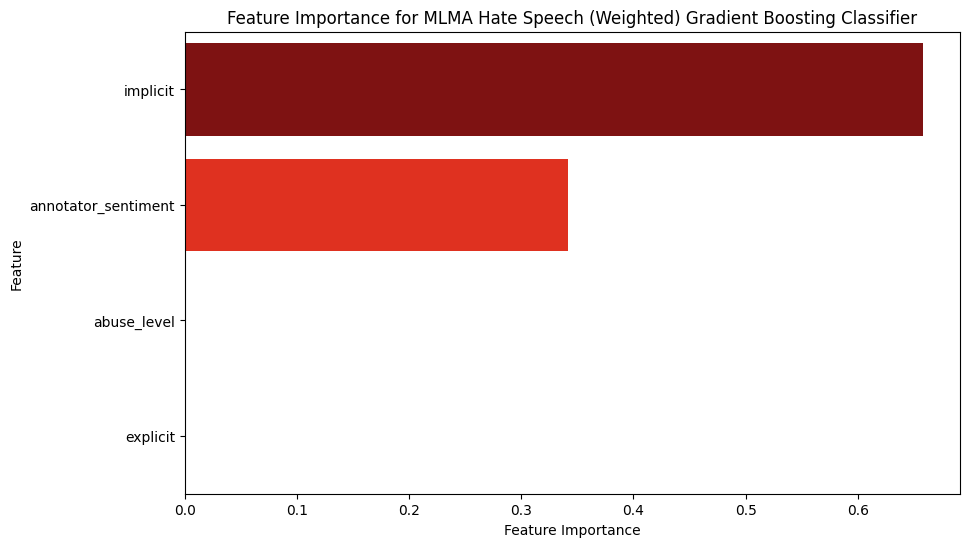

In [102]:
# Calculate feature importance for the model
mlma_hate_speech_gb_feature_importance = mlma_hate_speech_gb_best_estimator.named_steps['xgb'].feature_importances_

# Sort the results by importance mean
mlma_hate_speech_gb_feature_importance_idx = mlma_hate_speech_gb_feature_importance.argsort()[::-1]
mlma_hate_speech_gb_sorted_feature_importance = mlma_hate_speech_gb_feature_importance[mlma_hate_speech_gb_feature_importance_idx]  # Sort the results by importance mean

# Save the sorted results as a dictionary
mlma_hate_speech_gb_sorted_feature_importance_dict = {}
for i, feature in enumerate(mlma_hate_speech_gb_sorted_feature_importance):
    mlma_hate_speech_gb_sorted_feature_importance_dict[mlma_hate_speech_X_numeric.columns[mlma_hate_speech_gb_feature_importance_idx[i]]] = feature

# Display the results
print("Feature Importance for MLMA Hate Speech Gradient Boosting Classifier:")
print(mlma_hate_speech_gb_feature_importance)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=mlma_hate_speech_gb_sorted_feature_importance, y=mlma_hate_speech_X_numeric.columns[mlma_hate_speech_gb_feature_importance_idx], palette="hot")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title(f"Feature Importance for MLMA Hate Speech ({balance}) Gradient Boosting Classifier")
plt.show()

In [103]:
# Append details to the results list
gb_classification_results_list.append((
    "Gradient Boosting",
    "MLMA Hate Speech",
    "NA",
    "NA",
    mlma_hate_speech_gb_accuracy,
    mlma_hate_speech_gb_f1,
    0.0,
    mlma_hate_speech_gb_grid_search.best_params_,
    mlma_hate_speech_gb_sorted_feature_importance_dict,
    balance
))

## Support Vector Machine Conclusions

In [104]:
gb_classification_results_list

[('Gradient Boosting',
  'Convabuse',
  'NA',
  'NA',
  0.8855325914149443,
  0.8520266948557892,
  0.0,
  {'xgb__learning_rate': np.float64(0.01),
   'xgb__max_depth': 1,
   'xgb__min_child_weight': 10,
   'xgb__n_estimators': 1},
  {'system': np.float32(0.6144965),
   'explicit': np.float32(0.3855035),
   'implicit': np.float32(0.0),
   'target_groups': np.float32(0.0),
   'individual': np.float32(0.0),
   'generalised': np.float32(0.0),
   'bot': np.float32(0.0),
   'annotator_id': np.float32(0.0)},
  'Weighted'),
 ('Gradient Boosting',
  'Dynamically Generated Hate Speech',
  'NA',
  'NA',
  0.5350512945774304,
  0.5181276221763418,
  0.0,
  {'xgb__learning_rate': np.float64(0.01),
   'xgb__max_depth': 1,
   'xgb__min_child_weight': 32,
   'xgb__n_estimators': 1},
  {'annotator': np.float32(1.0),
   'original': np.float32(0.0),
   'target_groups': np.float32(0.0),
   'type': np.float32(0.0)},
  'Weighted'),
 ('Gradient Boosting',
  'Online Abusive Attacks',
  'NA',
  'NA',
  0.7580

In [105]:
# Convert the gb_classification_results_list to a DataFrame
gb_classification_summary = pd.DataFrame(gb_classification_results_list, columns=["Model", "Dataset", "Kernel", "Regularization", "Accuracy", "F1-score", "Ratio", "Best Parameters", "Feature Importances", "Balance"])
gb_classification_summary

,Model,Dataset,Kernel,Regularization,Accuracy,F1-score,Ratio,Best Parameters,Feature Importances,Balance
0,Gradient Boosting,Convabuse,NA,NA,0.885533,0.852027,0.0,"{'xgb__learning_rate': 0.01, 'xgb__max_depth':...","{'system': 0.6144965, 'explicit': 0.3855035, '...",Weighted
1,Gradient Boosting,Dynamically Generated Hate Speech,NA,NA,0.535051,0.518128,0.0,"{'xgb__learning_rate': 0.01, 'xgb__max_depth':...","{'annotator': 1.0, 'original': 0.0, 'target_gr...",Weighted
2,Gradient Boosting,Online Abusive Attacks,NA,NA,0.758099,0.729504,"{'xgb__learning_rate': 0.01, 'xgb__max_depth':...","{'Toxic parent tweets': 1.0, 'Toxic replies': ...",Weighted,None
3,Gradient Boosting,US Elections 2020 Hate Speech,NA,NA,0.601002,0.668059,0.0,"{'xgb__learning_rate': 0.01, 'xgb__max_depth':...","{'Trump': 1.0, 'West': 0.0, 'Biden': 0.0}",Weighted
4,Gradient Boosting,MLMA Hate Speech,NA,NA,0.182744,0.120676,0.0,"{'xgb__learning_rate': 0.020000000000000004, '...","{'implicit': 0.6580093, 'annotator_sentiment':...",Weighted


In [106]:
gb_classification_summary.to_csv(f"{results_path}/model9_gb-classification-summary-xgb-{name}.csv", index=False)